<a href="https://colab.research.google.com/github/hulwene/DoAnML/blob/main/DenseNet_Workspace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 DoAnML - DenseNet-40 Custom
**Kiến trúc**: DenseNet-40 (L=40, k=12) | **Nâng cấp**: Mish + SE Block | **Dataset**: CIFAR-10

### Cấu trúc dự án
| File | Chức năng |
|------|----------|
| `model.py` | Kiến trúc DenseNet (SEBlock, DenseLayer, DenseBlock, TransitionLayer, DenseNetCustom) |
| `data_loader.py` | Tải và xử lý dữ liệu CIFAR-10 (Data Augmentation) |
| `train.py` | Hàm huấn luyện, đánh giá, lưu checkpoint |
| `utils.py` | Vẽ biểu đồ Loss/Accuracy |

## 1. Cài đặt Môi trường

In [1]:
from google.colab import drive
import os

# Kết nối với Google Drive
drive.mount('/content/drive')

# Tạo thư mục dự án nếu chưa có và di chuyển vào đó
project_folder = '/content/drive/MyDrive/DenseNet_Project'
if not os.path.exists(project_folder):
    os.makedirs(project_folder)

%cd {project_folder}

Mounted at /content/drive
/content/drive/MyDrive/DenseNet_Project


In [15]:
import os
import sys

# 1. Thông tin repo
GITHUB_USERNAME = "hulwene"
REPO_NAME = "DoAnML"
REPO_URL = f"https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"
PROJECT_ROOT = "/content/drive/MyDrive/DenseNet_Project"

# Di chuyển về thư mục gốc của dự án trên Drive
if not os.path.exists(PROJECT_ROOT):
    os.makedirs(PROJECT_ROOT)
%cd {PROJECT_ROOT}

# 2. Làm sạch và Clone lại để đảm bảo đủ file
if os.path.exists(REPO_NAME):
    print(f"--- Đang làm mới thư mục {REPO_NAME} ---")
    !rm -rf {REPO_NAME}

print(f"--- Đang clone {REPO_NAME} từ {REPO_URL} ---")
!git clone {REPO_URL}

# 3. Thiết lập đường dẫn hệ thống
working_dir = os.path.abspath(REPO_NAME)
if working_dir not in sys.path:
    sys.path.append(working_dir)

# Di chuyển vào trong repo
%cd {working_dir}

# 4. Kiểm tra sự tồn tại của các file quan trọng
print("\n--- Kiểm tra các file module ---")
required_files = ['model.py', 'train.py', 'data_loader.py', 'utils.py']
for f in required_files:
    status = "✅" if os.path.exists(f) else "❌"
    print(f"{status} {f}")

# 5. Cài đặt thư viện
if os.path.exists("requirements.txt"):
    !pip install -r requirements.txt

import torch
if torch.cuda.is_available():
    print(f"\nGPU: {torch.cuda.get_device_name(0)}")
else:
    print("\n⚠️ Chưa bật GPU!")

/content/drive/MyDrive/DenseNet_Project
--- Đang làm mới thư mục DoAnML ---
--- Đang clone DoAnML từ https://github.com/hulwene/DoAnML.git ---
Cloning into 'DoAnML'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 65 (delta 28), reused 15 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (65/65), 93.67 KiB | 1.36 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/drive/MyDrive/DenseNet_Project/DoAnML

--- Kiểm tra các file module ---
✅ model.py
✅ train.py
✅ data_loader.py
✅ utils.py

GPU: Tesla T4


## 2. Tải Dữ liệu CIFAR-10

In [9]:
from data_loader import get_data_loaders

trainloader, testloader = get_data_loaders()

print(f"Số batch huấn luyện: {len(trainloader)}")
print(f"Số batch kiểm thử: {len(testloader)}")

100%|██████████| 170M/170M [00:05<00:00, 30.0MB/s]


Số batch huấn luyện: 782
Số batch kiểm thử: 157


## 3. Khởi tạo Mô hình DenseNet-40 Custom

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import sys
import os

# Lấy đường dẫn hiện tại và đường dẫn cha
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)

# Kiểm tra file model.py ở các vị trí khả nghi và thêm vào sys.path
found = False
for path in [current_dir, parent_dir, os.path.join(parent_dir, 'DoAnML')]:
    if os.path.exists(os.path.join(path, 'model.py')):
        if path not in sys.path:
            sys.path.append(path)
        print(f"✅ Đã tìm thấy 'model.py' tại: {path}")
        found = True
        break

try:
    from model import DenseNetCustom
    print("✅ Import module 'model' thành công!")
except ModuleNotFoundError:
    print("❌ Vẫn không tìm thấy 'model.py'.")
    print("Thử liệt kê file trong thư mục hiện tại để debug:")
    !ls
    raise

# 1. Thiết bị tính toán
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Số vòng huấn luyện
num_epochs = 50

# 3. Khởi tạo mô hình DenseNet-40 (k=12)
model = DenseNetCustom(
    growth_rate=12,
    block_config=(12, 12, 12),
    num_classes=10
)
model = model.to(device)

# In tổng số tham số
total_params = sum(p.numel() for p in model.parameters())
print(f"Tổng số tham số: {total_params:,}")

# 4. Hàm mất mát và Bộ tối ưu
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Cosine Annealing Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

print(f"✅ Đã khởi tạo mô hình trên thiết bị: {device}")

✅ Đã tìm thấy 'model.py' tại: /content/drive/MyDrive/DenseNet_Project/DoAnML
✅ Import module 'model' thành công!
Tổng số tham số: 617,050
✅ Đã khởi tạo mô hình trên thiết bị: cuda


In [12]:
import os
print("Thư mục hiện tại:", os.getcwd())
print("Nội dung thư mục hiện tại:")
!ls
print("\nKiểm tra sâu hơn:")
!ls -R | grep ":$" -A 5

Thư mục hiện tại: /content/drive/MyDrive/DenseNet_Project/DoAnML/DoAnML
Nội dung thư mục hiện tại:
data			  DoAnML	 README.md
DenseNet_Workspace.ipynb  push_test.txt  requirements.txt

Kiểm tra sâu hơn:
.:
data
DenseNet_Workspace.ipynb
DoAnML
push_test.txt
README.md
--
./data:
cifar-10-batches-py
cifar-10-python.tar.gz

./data/cifar-10-batches-py:
batches.meta
data_batch_1
data_batch_2
data_batch_3
data_batch_4
--
./DoAnML:
data
DenseNet_Workspace.ipynb
push_test.txt
README.md
requirements.txt
--
./DoAnML/data:
cifar-10-python.tar.gz


## 4. Huấn luyện Mô hình

In [17]:
from train import train_one_epoch, evaluate, save_checkpoint

# Mảng lưu lịch sử để vẽ biểu đồ
train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

print("🚀 BẮT ĐẦU HUẤN LUYỆN...")
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 20)

    # Chạy Train và Test
    train_loss, train_acc = train_one_epoch(model, trainloader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, testloader, criterion, device)

    # Cập nhật tốc độ học
    scheduler.step()

    # Lưu lại kết quả
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test  Loss: {test_loss:.4f}  | Test  Acc: {test_acc:.2f}%")
    print(f"Learning Rate hiện tại: {scheduler.get_last_lr()[0]:.6f}")

    # Lưu model mỗi 10 epoch
    if (epoch + 1) % 10 == 0:
        save_checkpoint(model, optimizer, scheduler, epoch + 1)

print("\n🎉 HOÀN TẤT HUẤN LUYỆN!")

🚀 BẮT ĐẦU HUẤN LUYỆN...

Epoch 1/50
--------------------
Train Loss: 1.4032 | Train Acc: 48.20%
Test  Loss: 1.1335  | Test  Acc: 59.37%
Learning Rate hiện tại: 0.000999

Epoch 2/50
--------------------
Train Loss: 0.9637 | Train Acc: 65.45%
Test  Loss: 0.8655  | Test  Acc: 69.40%
Learning Rate hiện tại: 0.000996

Epoch 3/50
--------------------
Train Loss: 0.7751 | Train Acc: 72.45%
Test  Loss: 0.6857  | Test  Acc: 75.82%
Learning Rate hiện tại: 0.000991

Epoch 4/50
--------------------
Train Loss: 0.6586 | Train Acc: 76.91%
Test  Loss: 0.7302  | Test  Acc: 74.62%
Learning Rate hiện tại: 0.000984

Epoch 5/50
--------------------
Train Loss: 0.5825 | Train Acc: 79.71%
Test  Loss: 0.5882  | Test  Acc: 79.63%
Learning Rate hiện tại: 0.000976

Epoch 6/50
--------------------
Train Loss: 0.5269 | Train Acc: 81.61%
Test  Loss: 0.5431  | Test  Acc: 81.25%
Learning Rate hiện tại: 0.000965

Epoch 7/50
--------------------
Train Loss: 0.4843 | Train Acc: 83.34%
Test  Loss: 0.5069  | Test  Acc: 8

## 5. Trực quan hóa Kết quả

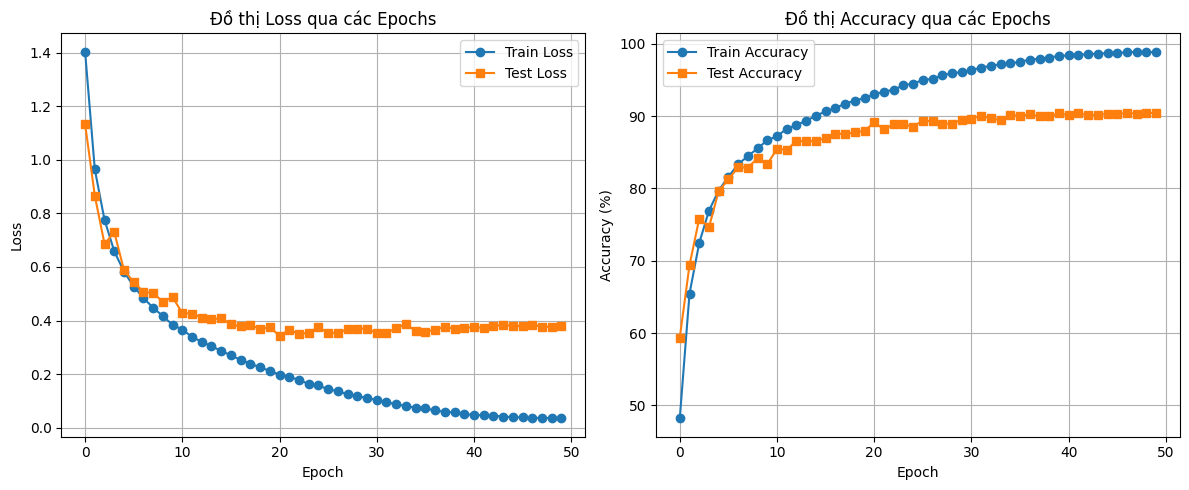

In [18]:
from utils import plot_training_history

plot_training_history(train_losses, test_losses, train_accuracies, test_accuracies)